# Test1


In [8]:
import numpy as np
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from scikeras.wrappers import KerasClassifier

# IMPORTANT: this should import from your local editable install
from trustcv import TrustCVValidator

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)


def build_mlp_softmax(input_dim, lr=1e-3):
    """
    Softmax(2) output guarantees:
    - predict() -> labels (n,)
    - predict_proba() -> (n,2)
    This is the most robust for sklearn-style metrics.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(2, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model


def main():
    X, y = load_breast_cancer(return_X_y=True)
    X = X.astype("float32")
    y = y.astype("int32")

    keras_clf = KerasClassifier(
        model=build_mlp_softmax,
        model__input_dim=X.shape[1],
        epochs=5,          # keep small for a quick local check
        batch_size=32,
        verbose=0,
    )

    pipe = make_pipeline(StandardScaler(), keras_clf)

    validator = TrustCVValidator(
        method="StratifiedKFold",
        n_splits=5,
        shuffle=True,
        random_state=SEED,
        check_leakage=True,
        check_balance=True,
        # if you added debug: debug=True,
    )

    result = validator.validate(model=pipe, X=X, y=y)

    # --- required checks (these MUST pass after your patch) ---
    assert isinstance(result.mean_scores, dict), "mean_scores must be a dict"
    assert "accuracy" in result.mean_scores, "accuracy missing from mean_scores"
    assert "roc_auc" in result.mean_scores, "roc_auc missing from mean_scores"

    for k in ["accuracy", "roc_auc", "f1", "precision", "recall", "sensitivity", "specificity"]:
        if k in result.mean_scores:
            v = result.mean_scores[k]
            assert np.isfinite(v), f"{k} is not finite: {v}"

    print(result.summary())


if __name__ == "__main__":
    main()


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.967 +/- 0.011 [95% CI (bootstrap): 0.956-0.974]
  roc_auc: 0.995 +/- 0.005 [95% CI (bootstrap): 0.990-0.999]
  sensitivity: 0.983 +/- 0.018 [95% CI (bootstrap): 0.967-0.997]
  specificity: 0.939 +/- 0.054 [95% CI (bootstrap): 0.897-0.981]
  precision: 0.965 +/- 0.030 [95% CI (bootstrap): 0.938-0.989]
  recall: 0.983 +/- 0.018 [95% CI (bootstrap): 0.969-0.997]
  f1: 0.974 +/- 0.008 [95% CI (bootstrap): 0.966-0.979]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [9]:
import pandas as pd
from trustcv.datasets import load_heart_disease

ds = load_heart_disease(as_frame=True)   # DataFrame/Series
X = ds.data
y = ds.target
groups = ds.patient_ids

print(ds.DESCR)
print("\nShape:", X.shape)
print("Feature names:", ds.feature_names)
print("Target distribution:\n", y.value_counts())

# Combine for a single table view
df = X.copy()
df["heart_disease"] = y
df["patient_id"] = groups

print("\nFirst 5 rows:")
print(df.head())

print("\nUnique patients:", groups.nunique())
print("\nRecords per patient (summary):")
print(groups.value_counts().describe())

print("\nTop repeated patients:")
print(groups.value_counts().head(10))


Synthetic heart disease dataset for demonstration.
Features include age, BMI, blood pressure, cholesterol, etc.
Target: 0 = no disease, 1 = disease.

Shape: (1000, 12)
Feature names: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'hdl', 'ldl', 'glucose', 'smoking', 'diabetes', 'family_history', 'exercise']
Target distribution:
 1    585
0    415
Name: heart_disease, dtype: int64

First 5 rows:
         age        bmi  systolic_bp  diastolic_bp  cholesterol        hdl  \
0  43.401625  33.266759   155.853541     99.517199   212.499012  49.179340   
1  49.738161  24.632393   145.049844     88.444638   236.142742  33.617119   
2  58.273341  28.488316   170.434205    103.959142   225.459322  40.873632   
3  68.658462  23.507774   111.523913     68.324361   238.098428  44.433371   
4  70.829965  38.779557   127.401503     77.239490   186.493136  37.963633   

          ldl     glucose  smoking  diabetes  family_history  exercise  \
0  143.319672  112.452600        0         0  

In [10]:
import numpy as np
import tensorflow as tf

from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import trustcv
from trustcv import TrustCV, load_heart_disease

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

print("trustcv version:", trustcv.__version__)
print("TrustCV class:", TrustCV)

# -------------------------
# Load dataset with groups
# -------------------------
ds = load_heart_disease(as_frame=False)
X = ds.data.astype("float32")
y = ds.target.astype("int32")
groups = ds.patient_ids.to_numpy()

print("X:", X.shape, "y:", y.shape, "unique groups:", len(np.unique(groups)))

# -------------------------
# Keras model (softmax -> stable predict/predict_proba)
# -------------------------
def build_mlp_softmax(input_dim, lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(2, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

clf = KerasClassifier(
    model=build_mlp_softmax,
    model__input_dim=X.shape[1],
    epochs=5,
    batch_size=32,
    verbose=0,
)

pipe = make_pipeline(StandardScaler(), clf)

# -------------------------
# 1) BAD: stratified_kfold ignores groups -> should FAIL leakage
# -------------------------
validator_bad = TrustCV(
    method="stratified_kfold",
    n_splits=3,
    random_state=SEED,
    check_leakage=True,
    check_balance=True,
)

res_bad = validator_bad.validate(model=pipe, X=X, y=y, groups=groups)

print("\n--- BAD (stratified_kfold) ---")
print("mean_scores:", res_bad.mean_scores)
print("leakage_check:", res_bad.leakage_check)
print(res_bad.summary())

# Assertions: after your patch, metrics should NOT be empty
assert isinstance(res_bad.mean_scores, dict)
assert len(res_bad.mean_scores) > 0, "mean_scores is empty -> prediction normalization still broken"
assert "accuracy" in res_bad.mean_scores, "accuracy missing"
assert "roc_auc" in res_bad.mean_scores, "roc_auc missing"

# Should detect group leakage
assert res_bad.leakage_check.get("no_patient_leakage") is False, "Expected patient leakage for stratified_kfold"

# -------------------------
# 2) GOOD: grouped stratified kfold -> should PASS leakage
# -------------------------
validator_good = TrustCV(
    method="stratified_grouped_kfold",
    n_splits=3,
    random_state=SEED,
    check_leakage=True,
    check_balance=True,
)

res_good = validator_good.validate(model=pipe, X=X, y=y, groups=groups)

print("\n--- GOOD (stratified_grouped_kfold) ---")
print("mean_scores:", res_good.mean_scores)
print("leakage_check:", res_good.leakage_check)
print(res_good.summary())

assert len(res_good.mean_scores) > 0, "mean_scores is empty in grouped CV"
assert res_good.leakage_check.get("no_patient_leakage") is True, "Expected no patient leakage for grouped CV"

print("\n✅ All checks passed. Your TrustCV patch is working.")


trustcv version: 1.0.5
TrustCV class: <class 'trustcv.validators.TrustCVValidator'>
X: (1000, 12) y: (1000,) unique groups: 557


/home/amir/Umea_Desctop/AAA_test/p4_CV/P4_paper/Repo/trustcv26012026/trustcv/validators.py:1372: UserWarning: Group leakage detected: some group/patient IDs appear in both train and test folds.
  warnings.warn(



--- BAD (stratified_kfold) ---
mean_scores: {'accuracy': 0.571976167784551, 'roc_auc': 0.5449348436523914, 'sensitivity': 0.8273504273504274, 'specificity': 0.21216070621763458, 'precision': 0.5964628238490368, 'recall': 0.8273504273504274, 'f1': 0.6920293706498452}
leakage_check: {'no_duplicate_samples': True, 'no_patient_leakage': False, 'balanced_classes': True}
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.572 +/- 0.025 [95% CI (bootstrap): 0.547-0.596]
  roc_auc: 0.545 +/- 0.032 [95% CI (bootstrap): 0.510-0.571]
  sensitivity: 0.827 +/- 0.090 [95% CI (bootstrap): 0.728-0.903]
  specificity: 0.212 +/- 0.068 [95% CI (bootstrap): 0.165-0.290]
  precision: 0.596 +/- 0.006 [95% CI (bootstrap): 0.592-0.603]
  recall: 0.827 +/- 0.090 [95% CI (bootstrap): 0.728-0.903]
  f1: 0.692 +/- 0.036 [95% CI (bootstrap): 0.669-0.723]

Data Integrity Checks:
  Leakage Check: FAILED
  Class Balance: PASSED


--- GOOD (stratified_gr

X: (8000, 28, 28, 1) y: (8000,) classes: [0 1 2 3 4 5 6 7 8 9]


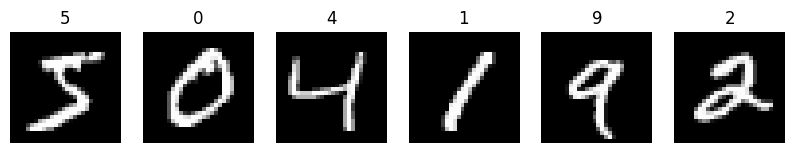


=== Normal CV (manual StratifiedKFold) ===
Fold 1: accuracy=0.9408
Fold 2: accuracy=0.9295
Fold 3: accuracy=0.9415
Normal CV mean accuracy: 0.9373 +/- 0.0055

=== TrustCV ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.928 +/- 0.002 [95% CI (bootstrap): 0.925-0.930]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

from trustcv import TrustCVValidator

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -------------------------
# Step A) Load MNIST (available everywhere)
# -------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Use a smaller subset to make CV fast (increase if you want)
N = 8000
x = x_train[:N]
y = y_train[:N]

# Normalize + add channel dim: (N, 28, 28, 1)
x = (x.astype("float32") / 255.0)[..., None]
y = y.astype("int32")

print("X:", x.shape, "y:", y.shape, "classes:", np.unique(y))

# Show a few images
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x[i, :, :, 0], cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.show()

# -------------------------
# Step B) Define a CNN builder
# -------------------------
def build_cnn(num_classes=10, lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(16, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# -------------------------
# Step C) A minimal sklearn-compatible wrapper for Keras
#         (so TrustCV can call fit/predict/predict_proba)
# -------------------------
class KerasImageWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_fn, epochs=2, batch_size=64, verbose=0):
        self.model_fn = model_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self._is_fitted = False

    def fit(self, X, y):
        self.model_ = self.model_fn()
        self.classes_ = np.unique(y)
        self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose
        )
        self._is_fitted = True
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "_is_fitted")
        proba = self.model_.predict(X, batch_size=self.batch_size, verbose=0)
        # Ensure 2D (n, C)
        proba = np.asarray(proba)
        if proba.ndim == 1:
            proba = np.column_stack([1 - proba, proba])
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

# Instantiate model wrapper
est = KerasImageWrapper(model_fn=lambda: build_cnn(num_classes=10), epochs=2, batch_size=64, verbose=0)

# -------------------------
# Step D) NORMAL CV (manual)
# -------------------------
print("\n=== Normal CV (manual StratifiedKFold) ===")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
fold_acc = []

for fold, (tr, te) in enumerate(skf.split(x, y), 1):
    est_fold = KerasImageWrapper(model_fn=lambda: build_cnn(num_classes=10),
                                 epochs=2, batch_size=64, verbose=0)
    est_fold.fit(x[tr], y[tr])
    y_pred = est_fold.predict(x[te])
    acc = (y_pred == y[te]).mean()
    fold_acc.append(acc)
    print(f"Fold {fold}: accuracy={acc:.4f}")

print(f"Normal CV mean accuracy: {np.mean(fold_acc):.4f} +/- {np.std(fold_acc):.4f}")

# -------------------------
# Step E) TRUSTCV (same estimator)
# -------------------------
print("\n=== TrustCV ===")
validator = TrustCVValidator(
    method="stratified_kfold",
    n_splits=3,
    random_state=SEED,
    shuffle=True,
    check_leakage=True,
    check_balance=True,
   # metrics=["accuracy"],  # multiclass-safe
)

result = validator.validate(model=est, X=x, y=y)
print(result.summary())


X: (8000, 28, 28, 1) y: (8000,) classes: [0 1 2 3 4 5 6 7 8 9]


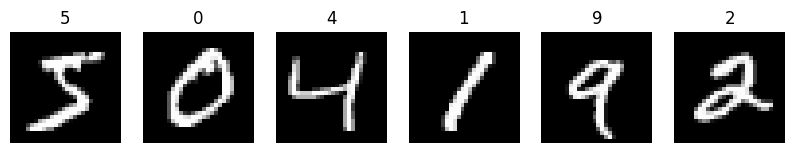


Starting Universal Cross-Validation (MNIST)...
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 5333
  Validation samples: 2667
  Train class distribution: 0: 530 (9.9%), 1: 604 (11.3%), 2: 526 (9.9%), 3: 540 (10.1%), 4: 532 (10.0%), 5: 468 (8.8%), 6: 532 (10.0%), 7: 569 (10.7%), 8: 502 (9.4%), 9: 530 (9.9%)
  Val class distribution:   0: 265 (9.9%), 1: 302 (11.3%), 2: 262 (9.8%), 3: 271 (10.2%), 4: 267 (10.0%), 5: 234 (8.8%), 6: 266 (10.0%), 7: 284 (10.6%), 8: 251 (9.4%), 9: 265 (9.9%)
Fold 1 completed
  score: 0.9385
  accuracy: 0.9385
  balanced_accuracy: 0.9386
  f1_macro: 0.9379
  precision_macro: 0.9385
  recall_macro: 0.9386
  roc_auc_ovr_macro: 0.9967

Fold 2:
  Training samples: 5333
  Validation samples: 2667
  Train class distribution: 0: 530 (9.9%), 1: 604 (11.3%), 2: 525 (9.8%), 3: 541 (10.1%), 4: 533 (10.0%), 5: 468 (8.8%), 6: 532 (10.0%), 7: 568 (10.7%), 8: 502 (9.4%), 9: 530 (9.9%)
  Val class distribution:   0: 2

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin

from trustcv.core.runner import UniversalCVRunner
from trustcv import ClassDistributionLogger
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap  # or KerasClassifierWrap

# -------------------------
# Seeds
# -------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -------------------------
# Step A) Load MNIST
# -------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

N = 8000  # smaller subset for speed
x = (x_train[:N].astype("float32") / 255.0)[..., None]  # (N,28,28,1)
y = y_train[:N].astype("int32")

print("X:", x.shape, "y:", y.shape, "classes:", np.unique(y))

# Show a few images
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x[i, :, :, 0], cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.show()

# -------------------------
# Step B) Keras model factory (CNN)
# -------------------------
def build_mnist_cnn():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m



# -------------------------
# Step D) CV splitter
# -------------------------
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# -------------------------
# Step E) Runner + callback (class distribution logger)
# -------------------------
runner = UniversalCVRunner(cv_splitter=cv_splitter, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=y,
    verbose=1,
    decimals=1
)

model = KerasSkWrap(build_mnist_cnn, epochs=2, batch_size=64, verbose=0)

print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=model,
    data=(x, y),
    callbacks=[class_logger]
)



In [13]:
# -------------------------
# Step C) Thin sklearn wrapper (same idea as your digits code)
# -------------------------
class KerasSkWrap(BaseEstimator, ClassifierMixin):
    def __init__(self, build_fn, epochs=2, batch_size=64, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model_ = self.build_fn()
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict_proba(self, X):
        return self.model_.predict(X, batch_size=self.batch_size, verbose=0)  # (n,10)

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

In [14]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import load_digits

from trustcv.core.runner import UniversalCVRunner
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap  # or KerasClassifierWrap

# ----- Data -----
X, y = load_digits(return_X_y=True)
X = X.astype("float32") / 16.0

# ----- Keras model factory -----
def build_mlp(input_shape, n_classes, hidden=64):
    import tensorflow as tf  # lazy import keeps TF optional elsewhere
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=input_shape),
            tf.keras.layers.Dense(hidden, activation="relu"),
            tf.keras.layers.Dense(n_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ----- Wrapper instance (fresh model each fit) -----
clf = KerasSkWrap(
    build_fn=build_mlp,
    epochs=3,
    batch_size=64,
    verbose=0,
    proba_mode="auto",   # "auto" | "sigmoid" | "softmax"
    threshold=0.5,
)

# ----- CV runner -----
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=1)

results = runner.run(model=clf, data=(X, y))

# ----- Per-fold metrics -----
import pandas as pd
df = pd.DataFrame(results.scores)
print("Per-fold metrics:\n", df)

# ----- Summary -----
print("\nSummary:", results.metrics)
print("\nMean accuracy:", results.metrics.get("accuracy", {}).get("mean"))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 1198
  Validation samples: 599


Fold 1 completed

Fold 2:
  Training samples: 1198
  Validation samples: 599
Fold 2 completed

Fold 3:
  Training samples: 1198
  Validation samples: 599
Fold 3 completed

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.7618 (+/- 0.0127)
  accuracy: 0.7618 (+/- 0.0127)
  balanced_accuracy: 0.7615 (+/- 0.0130)
  f1_macro: 0.7530 (+/- 0.0169)
  precision_macro: 0.7703 (+/- 0.0178)
  recall_macro: 0.7615 (+/- 0.0130)
  roc_auc_ovr_macro: 0.9585 (+/- 0.0066)
Per-fold metrics:
       score                                        predictions  \
0  0.751252  [0, 1, 6, 0, 0, 4, 3, 2, 3, 0, 6, 7, 7, 3, 0, ...   
1  0.754591  [3, 9, 7, 1, 1, 1, 9, 0, 9, 4, 1, 2, 1, 3, 3, ...   
2  0.779633  [8, 4, 9, 2, 3, 6, 7, 1, 0, 5, 9, 5, 5, 8, 7, ...   

                                       probabilities  accuracy  \
0  [[0.2974305, 0.06564724, 0.06118833, 0.0722107...  0.751252   
1  [[0.05230328, 0.12646848, 0.1098799, 0.1655301...  0.754591   
2  [[0.058100026, 0.1469574, 0.129

In [15]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

X, Y = make_multilabel_classification(
    n_samples=1500, n_features=30, n_classes=5, n_labels=2,
    allow_unlabeled=False, random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")


def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss="binary_crossentropy")
    return m

model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=5,
    batch_size=64,
    verbose=0,
    task="multilabel",
    threshold=0.5,
)

# Multilabel-safe scorers
scoring = {
    "f1_samples": make_scorer(f1_score, average="samples"),
    "f1_macro": make_scorer(f1_score, average="macro"),
}

v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
v.debug = False  # set True to print any scorer errors
res = v.validate(model=model, X=X, y=Y, scoring=scoring)

print(res.summary())
print("Mean scores:", res.mean_scores)


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  f1_samples: 0.809 +/- 0.018 [95% CI (bootstrap): 0.789-0.823]
  f1_macro: 0.731 +/- 0.019 [95% CI (bootstrap): 0.711-0.748]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED

Mean scores: {'f1_samples': 0.8086095238095239, 'f1_macro': 0.7314906794637706}


In [16]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from trustcv.core.runner import UniversalCVRunner
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# data
X, Y = make_multilabel_classification(
    n_samples=1500, n_features=30, n_classes=5, n_labels=2,
    allow_unlabeled=False, random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")

# model factory
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return m

# wrapper (multilabel)
clf = KerasSkWrap(build_fn=build_mlp, epochs=5, batch_size=64, verbose=0,
                  task="multilabel", threshold=0.5)

# runner
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=1)
results = runner.run(model=clf, data=(X, Y))

# post-hoc multilabel metrics per fold
rows = []
for (tr_idx, te_idx), proba in zip(results.indices, results.probabilities):
    y_true = Y[te_idx]
    y_pred = (proba >= 0.5).astype(int)
    rows.append({
        "f1_samples": f1_score(y_true, y_pred, average="samples"),
        "f1_macro":   f1_score(y_true, y_pred, average="macro"),
    })

print("Per-fold multilabel F1:", rows)
print("Mean f1_samples:", np.mean([r["f1_samples"] for r in rows]))
print("Mean f1_macro:",   np.mean([r["f1_macro"]   for r in rows]))


Using sklearn adapter for cross-validation
Starting 3-fold cross-validation


ValueError: Supported target types are: ('binary', 'multiclass'). Got 'multilabel-indicator' instead.

In [ ]:
import numpy as np
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
np.random.seed(SEED)

# --- Data ---
X, Y = make_multilabel_classification(
    n_samples=600,
    n_features=30,
    n_classes=5,
    n_labels=2,
    allow_unlabeled=False,
    random_state=SEED,
)
X = X.astype("float32")
Y = Y.astype("int32")

# --- Tiny multilabel model ---
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return m

model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=3,
    batch_size=64,
    verbose=0,
    task="multilabel",
    threshold=0.5,
)

# --- Multilabel-safe scorers ---
scoring = {
    "f1_samples": make_scorer(f1_score, average="samples"),
    "f1_macro": make_scorer(f1_score, average="macro"),
}

# --- Validator ---
v = TrustCVValidator(method="stratified_kfold", n_splits=3, shuffle=True, random_state=SEED)
v.debug = True  # to see any scorer/model errors

res = v.validate(model=model, X=X, y=Y, scoring=scoring)

print(res.summary())
print("Mean scores:", res.mean_scores)
print("Per-fold details:", res.fold_details[:2], "...")  # first two folds as a peek


2026-01-30 10:39:58.096488: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 10:39:58.102265: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 10:39:58.121725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-30 10:39:58.157832: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-30 10:39:58.157886: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 10:39:58.190935: I tensorflow/core/platform/cpu_feature_guard.cc:

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  f1_samples: 0.637 +/- 0.023 [95% CI (bootstrap): 0.614-0.660]
  f1_macro: 0.505 +/- 0.006 [95% CI (bootstrap): 0.498-0.510]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED

Mean scores: {'f1_samples': 0.6373320105820106, 'f1_macro': 0.5048222175535947}
Per-fold details: [{'fold': 1, 'n_train': 400, 'n_val': 200, 'metrics': {'f1_samples': 0.6377698412698413, 'f1_macro': 0.5067232393528192}}, {'fold': 2, 'n_train': 400, 'n_val': 200, 'metrics': {'f1_samples': 0.6599880952380953, 'f1_macro': 0.5097631346930808}}] ...


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import KFold, StratifiedKFold
from trustcv.splitters.multilabel import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
from trustcv.core.runner import UniversalCVRunner
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap
from trustcv import ClassDistributionLogger


SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# data
X, Y = make_multilabel_classification(
    n_samples=600, n_features=30, n_classes=5, n_labels=2,
    allow_unlabeled=False, random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")

# model factory
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return m

# multilabel wrapper
clf = KerasSkWrap(build_fn=build_mlp, epochs=3, batch_size=64, verbose=0,
                  task="multilabel", threshold=0.5)

# CV splitter (use KFold; StratifiedKFold cannot handle multilabel)
cv = MultilabelStratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

results = runner.run(model=clf, data=(X, Y))

# Per-fold multilabel F1
rows = []
for (train_idx, test_idx), proba in zip(results.indices, results.probabilities):
    y_true = Y[test_idx]
    y_pred = (proba >= 0.5).astype(int)
    rows.append({
        "f1_samples": f1_score(y_true, y_pred, average="samples"),
        "f1_macro":   f1_score(y_true, y_pred, average="macro"),
    })

print("Per-fold metrics:", rows)
print("Mean f1_samples:", np.mean([r["f1_samples"] for r in rows]))
print("Mean f1_macro:",   np.mean([r["f1_macro"]   for r in rows]))

# You can also inspect runner's default per-fold scores:
# print(results.scores)

# -------------------------
# Step E) Runner + callback (class distribution logger)
# -------------------------
runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=Y,
    verbose=1,
    decimals=1
)



print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=clf,
    data=(X, Y),
    callbacks=[class_logger]
)


2026-01-30 11:15:00.816141: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 11:15:00.939482: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 11:15:01.096406: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-30 11:15:01.263622: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-30 11:15:01.264803: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 11:15:01.493725: I tensorflow/core/platform/cpu_feature_guard.cc:

Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 388
  Validation samples: 212
Fold 1 completed
  score: 0.1132
  accuracy: 0.1132
  roc_auc_ovr_macro: 0.6436
  f1_samples: 0.6078
  f1_macro: 0.4866

Fold 2:
  Training samples: 398
  Validation samples: 202
Fold 2 completed
  score: 0.1832
  accuracy: 0.1832
  roc_auc_ovr_macro: 0.7022
  f1_samples: 0.6474
  f1_macro: 0.4949

Fold 3:
  Training samples: 414
  Validation samples: 186
Fold 3 completed
  score: 0.1237
  accuracy: 0.1237
  roc_auc_ovr_macro: 0.7008
  f1_samples: 0.5885
  f1_macro: 0.4866

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.1400 (+/- 0.0310)
  accuracy: 0.1400 (+/- 0.0310)
  f1_macro: 0.4894 (+/- 0.0039)
  f1_samples: 0.6151 (+/- 0.0243)
  label_prevalence: 0.4493 (+/- 0.1572)
  roc_auc_ovr_macro: 0.6810 (+/- 0.0277)
Per-fold metrics: [{'f1_samples': 0.6077568134171909, 'f1_macro': 0.48658063850636957}, {'f1_samples': 0.64739509665

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from trustcv.core.runner import UniversalCVRunner
from trustcv.splitters.multilabel_group import MultilabelStratifiedGroupKFold
from trustcv import ClassDistributionLogger

SEED = 42
rng = np.random.default_rng(SEED)

# -------------------------
# Synthetic grouped multilabel data
# -------------------------
n_groups = 120
min_g, max_g = 6, 20
n_labels = 6
n_features = 25

group_sizes = rng.integers(min_g, max_g + 1, size=n_groups)
groups = np.concatenate([np.full(gs, gid) for gid, gs in enumerate(group_sizes)])
n = len(groups)

# group-level label propensity (rare labels exist)
label_base_p = np.array([0.35, 0.25, 0.15, 0.10, 0.06, 0.04])
G = rng.random((n_groups, n_labels)) < label_base_p  # each group has its own labelset

# sample labels inherit group labels with noise
Y = np.zeros((n, n_labels), dtype=np.int32)
start = 0
flip_p = 0.08
for gid, gs in enumerate(group_sizes):
    end = start + gs
    y_g = np.tile(G[gid].astype(np.int32), (gs, 1))
    flips = (rng.random((gs, n_labels)) < flip_p).astype(np.int32)
    y_g = np.clip(y_g ^ flips, 0, 1)
    # ensure at least 1 label for stability
    empty = np.where(y_g.sum(axis=1) == 0)[0]
    if len(empty) > 0:
        y_g[empty, rng.integers(0, n_labels, size=len(empty))] = 1
    Y[start:end] = y_g
    start = end

# features with weak signal from labels (so model has something to learn)
X = rng.normal(0, 1, size=(n, n_features)).astype(np.float32)
X[:, :n_labels] += (Y * 0.8).astype(np.float32)

print("X:", X.shape, "Y:", Y.shape, "groups:", groups.shape)
print("Global label prevalence:", Y.mean(axis=0).round(3))

# -------------------------
# Multilabel + group splitter
# -------------------------
cv = MultilabelStratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED, alpha=1.0, beta=0.5)

# sklearn multilabel classifier
clf = OneVsRestClassifier(LogisticRegression(max_iter=500))

runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

# IMPORTANT: pass groups in data tuple so runner can forward groups to splitter
results = runner.run(model=clf, data=(X, Y), groups=groups)

# -------------------------
# Per-fold diagnostics
# -------------------------
rows = []
for fold_idx, (tr, te) in enumerate(results.indices, start=1):
    # group leakage check
    g_tr = set(groups[tr])
    g_te = set(groups[te])
    assert g_tr.isdisjoint(g_te), "Group leakage detected!"

    # prevalence check
    prev = Y[te].mean(axis=0)

    # predictions: Many TrustCV builds store probabilities/preds; easiest is to recompute here:
    clf_fold = OneVsRestClassifier(LogisticRegression(max_iter=500))
    clf_fold.fit(X[tr], Y[tr])
    Yhat = clf_fold.predict(X[te])

    f1_samples = f1_score(Y[te], Yhat, average="samples")

    rows.append({
        "fold": fold_idx,
        "n_test": len(te),
        "n_groups_test": len(g_te),
        "f1_samples": f1_samples,
        **{f"prev_L{j}": float(prev[j]) for j in range(n_labels)}
    })

import pandas as pd
df = pd.DataFrame(rows)
print(df)
print("\nMean f1_samples:", df["f1_samples"].mean().round(4))


runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=Y,
    verbose=1,
    decimals=1
)



print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=clf,
    data=(X, Y),
    groups=groups,
    callbacks=[class_logger]
)



X: (1596, 25) Y: (1596, 6) groups: (1596,)
Global label prevalence: [0.457 0.367 0.297 0.193 0.189 0.14 ]
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 1075
  Validation samples: 521
  Training groups: 80
  Validation groups: 40
Fold 1 completed
  score: 0.1766
  accuracy: 0.1766
  roc_auc_ovr_macro: 0.7183
  f1_samples: 0.3908
  f1_macro: 0.3601
  f1_micro: 0.4572

Fold 2:
  Training samples: 1049
  Validation samples: 547
  Training groups: 79
  Validation groups: 41
Fold 2 completed
  score: 0.1554
  accuracy: 0.1554
  roc_auc_ovr_macro: 0.7228
  f1_samples: 0.3709
  f1_macro: 0.3532
  f1_micro: 0.4437

Fold 3:
  Training samples: 1068
  Validation samples: 528
  Training groups: 81
  Validation groups: 39
Fold 3 completed
  score: 0.1477
  accuracy: 0.1477
  roc_auc_ovr_macro: 0.7183
  f1_samples: 0.3570
  f1_macro: 0.3332
  f1_micro: 0.4336

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.1598 (+/-

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from trustcv.core.runner import UniversalCVRunner
from trustcv.splitters.multilabel_group import MultilabelStratifiedGroupKFold
from trustcv import ClassDistributionLogger

SEED = 42
rng = np.random.default_rng(SEED)

# -------------------------
# Synthetic grouped multilabel data
# -------------------------
n_groups = 120
min_g, max_g = 6, 20
n_labels = 6
n_features = 25

group_sizes = rng.integers(min_g, max_g + 1, size=n_groups)
groups = np.concatenate([np.full(gs, gid) for gid, gs in enumerate(group_sizes)])
n = len(groups)

# group-level label propensity (rare labels exist)
label_base_p = np.array([0.35, 0.25, 0.15, 0.10, 0.06, 0.04])
G = rng.random((n_groups, n_labels)) < label_base_p  # each group has its own labelset

# sample labels inherit group labels with noise
Y = np.zeros((n, n_labels), dtype=np.int32)
start = 0
flip_p = 0.08
for gid, gs in enumerate(group_sizes):
    end = start + gs
    y_g = np.tile(G[gid].astype(np.int32), (gs, 1))
    flips = (rng.random((gs, n_labels)) < flip_p).astype(np.int32)
    y_g = np.clip(y_g ^ flips, 0, 1)
    # ensure at least 1 label for stability
    empty = np.where(y_g.sum(axis=1) == 0)[0]
    if len(empty) > 0:
        y_g[empty, rng.integers(0, n_labels, size=len(empty))] = 1
    Y[start:end] = y_g
    start = end

# features with weak signal from labels (so model has something to learn)
X = rng.normal(0, 1, size=(n, n_features)).astype(np.float32)
X[:, :n_labels] += (Y * 0.8).astype(np.float32)

print("X:", X.shape, "Y:", Y.shape, "groups:", groups.shape)
print("Global label prevalence:", Y.mean(axis=0).round(3))

# -------------------------
# Multilabel + group splitter
# -------------------------
cv = MultilabelStratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED, alpha=1.0, beta=0.5)

# sklearn multilabel classifier
clf = OneVsRestClassifier(LogisticRegression(max_iter=500))

runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

# IMPORTANT: pass groups in data tuple so runner can forward groups to splitter
results = runner.run(model=clf, data=(X, Y, groups))

# -------------------------
# Per-fold diagnostics
# -------------------------
rows = []
for fold_idx, (tr, te) in enumerate(results.indices, start=1):
    # group leakage check
    g_tr = set(groups[tr])
    g_te = set(groups[te])
    assert g_tr.isdisjoint(g_te), "Group leakage detected!"

    # prevalence check
    prev = Y[te].mean(axis=0)

    # predictions: Many TrustCV builds store probabilities/preds; easiest is to recompute here:
    clf_fold = OneVsRestClassifier(LogisticRegression(max_iter=500))
    clf_fold.fit(X[tr], Y[tr])
    Yhat = clf_fold.predict(X[te])

    f1_samples = f1_score(Y[te], Yhat, average="samples")

    rows.append({
        "fold": fold_idx,
        "n_test": len(te),
        "n_groups_test": len(g_te),
        "f1_samples": f1_samples,
        **{f"prev_L{j}": float(prev[j]) for j in range(n_labels)}
    })

import pandas as pd
df = pd.DataFrame(rows)
print(df)
print("\nMean f1_samples:", df["f1_samples"].mean().round(4))


runner = UniversalCVRunner(cv_splitter=cv, framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=Y,
    verbose=1,
    decimals=1
)



print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=clf,
    data=(X, Y, groups),
    callbacks=[class_logger]
)



X: (1596, 25) Y: (1596, 6) groups: (1596,)
Global label prevalence: [0.457 0.367 0.297 0.193 0.189 0.14 ]
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 1075
  Validation samples: 521
Fold 1 completed
  score: 0.1766
  accuracy: 0.1766
  roc_auc_ovr_macro: 0.7183
  f1_samples: 0.3908
  f1_macro: 0.3601

Fold 2:
  Training samples: 1049
  Validation samples: 547
Fold 2 completed
  score: 0.1554
  accuracy: 0.1554
  roc_auc_ovr_macro: 0.7228
  f1_samples: 0.3709
  f1_macro: 0.3532

Fold 3:
  Training samples: 1068
  Validation samples: 528
Fold 3 completed
  score: 0.1477
  accuracy: 0.1477
  roc_auc_ovr_macro: 0.7183
  f1_samples: 0.3570
  f1_macro: 0.3332

Cross-validation completed

Cross-Validation Results Summary:
  score: 0.1598 (+/- 0.0121)
  accuracy: 0.1598 (+/- 0.0121)
  f1_macro: 0.3488 (+/- 0.0114)
  f1_samples: 0.3728 (+/- 0.0138)
  label_prevalence: 0.2739 (+/- 0.1115)
  roc_auc_ovr_macro: 0.7198 (+/- 0.0021)
   fold

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasRegressorWrap   # or KerasRegressorWrap if you made it

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

X, y = load_diabetes(return_X_y=True)
X = X.astype("float32")
y = y.astype("float32")

def build_regressor(input_shape, n_classes=None, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="linear")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return m

model = KerasRegressorWrap(
    build_fn=build_regressor,
    epochs=10,
    batch_size=64,
    verbose=0,
    task="regression"   # <-- important (or use your regressor wrapper)
)

scoring = {
    # leave MSE negative if you want “lower is better” semantics; or set True for positive
    "mse": make_scorer(mean_squared_error, greater_is_better=True),
    "rmse": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=True),
    "mae": make_scorer(mean_absolute_error, greater_is_better=True),
    "r2":  make_scorer(r2_score),
    "explained_variance": "explained_variance"
}

v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model=model, X=X, y=y, scoring=scoring)
#res = v.validate(model=model, X=X, y=y)

print(res.summary())
print("Mean scores:", res.mean_scores)

# sanity
yp = model.fit(X, y).predict(X[:5])
print("predict shape:", np.asarray(yp).shape, "values:", yp[:5])


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  mse: 28145.859 +/- 376.628 [95% CI (bootstrap): 27745.213-28492.676]
  rmse: 167.765 +/- 1.123 [95% CI (bootstrap): 166.569-168.798]
  mae: 149.169 +/- 3.147 [95% CI (bootstrap): 145.646-151.703]
  r2: -3.785 +/- 0.490 [95% CI (bootstrap): -4.165--3.231]
  explained_variance: 0.006 +/- 0.002 [95% CI (bootstrap): 0.004-0.007]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

Mean scores: {'mse': 28145.858723958332, 'rmse': 167.76476542154947, 'mae': 149.16937764485678, 'r2': -3.784600877914929, 'explained_variance': 0.005661427974700928}
predict shape: (5,) values: [5.8205633 4.4550805 5.6239104 5.3702188 5.241778 ]


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasRegressorWrap   # or KerasRegressorWrap if you made it

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

X, y = load_diabetes(return_X_y=True)
X = X.astype("float32")
y = y.astype("float32")

def build_regressor(input_shape, n_classes=None, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="linear")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return m

model = KerasRegressorWrap(
    build_fn=build_regressor,
    epochs=10,
    batch_size=64,
    verbose=0,
    task="regression"   # <-- important (or use your regressor wrapper)
)

scoring = {
    "rmse": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False),
    "r2": make_scorer(r2_score),
}

v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
#res = v.validate(model=model, X=X, y=y, scoring=scoring)
res = v.validate(model=model, X=X, y=y)

print(res.summary())
print("Mean scores:", res.mean_scores)

# sanity
yp = model.fit(X, y).predict(X[:5])
print("predict shape:", np.asarray(yp).shape, "values:", yp[:5])


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  mse: 28145.859 +/- 376.628 [95% CI (bootstrap): 27745.213-28492.676]
  rmse: 167.765 +/- 1.123 [95% CI (bootstrap): 166.569-168.798]
  mae: 149.169 +/- 3.147 [95% CI (bootstrap): 145.646-151.703]
  r2: -3.785 +/- 0.490 [95% CI (bootstrap): -4.165--3.231]
  explained_variance: 0.006 +/- 0.002 [95% CI (bootstrap): 0.004-0.007]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

Mean scores: {'mse': 28145.858723958332, 'rmse': 167.76476542154947, 'mae': 149.16937764485678, 'r2': -3.784600877914929, 'explained_variance': 0.005661427974700928}
predict shape: (5,) values: [5.8205633 4.4550805 5.6239104 5.3702188 5.241778 ]


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, make_scorer

from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

n = 1200
X1 = np.random.randn(n, 20).astype("float32")
X2 = np.random.randn(n, 10).astype("float32")
y  = (X1[:, 0] + 0.3*X2[:, 0] > 0).astype("int32")

X = {"x1": X1, "x2": X2}  # <-- multi-input

def build_multi_input(input_shape, n_classes, lr=1e-3):
    # input_shape must be dict-like if you infer it; otherwise supply fixed shapes
    in1 = tf.keras.layers.Input(shape=(20,), name="x1")
    in2 = tf.keras.layers.Input(shape=(10,), name="x2")
    a = tf.keras.layers.Dense(32, activation="relu")(in1)
    b = tf.keras.layers.Dense(16, activation="relu")(in2)
    x = tf.keras.layers.Concatenate()([a, b])
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m = tf.keras.Model([in1, in2], out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    return m

model = KerasSkWrap(
    build_fn=build_multi_input,
    epochs=5,
    batch_size=64,
    verbose=0,
    task="binary"
)

scoring = {"accuracy": "accuracy"}
v = TrustCVValidator(method="StratifiedKFold", n_splits=3, shuffle=True, random_state=SEED)
#res = v.validate(model=model, X=X, y=y, scoring=scoring)
res = v.validate(model=model, X=X, y=y)

print(res.summary())


2026-01-30 13:50:45.034000: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 13:50:45.153173: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 13:50:45.303569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-30 13:50:45.451272: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-30 13:50:45.452244: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 13:50:45.654049: I tensorflow/core/platform/cpu_feature_guard.cc:

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.783 +/- 0.041 [95% CI (bootstrap): 0.743-0.825]
  roc_auc: 0.856 +/- 0.054 [95% CI (bootstrap): 0.808-0.915]
  sensitivity: 0.818 +/- 0.062 [95% CI (bootstrap): 0.750-0.871]
  specificity: 0.744 +/- 0.027 [95% CI (bootstrap): 0.724-0.775]
  precision: 0.776 +/- 0.029 [95% CI (bootstrap): 0.754-0.809]
  recall: 0.818 +/- 0.062 [95% CI (bootstrap): 0.750-0.871]
  f1: 0.796 +/- 0.043 [95% CI (bootstrap): 0.767-0.839]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap
from trustcv import ClassDistributionLogger
from trustcv.core.runner import UniversalCVRunner
from sklearn.model_selection import StratifiedKFold

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

n=1200
X = np.random.randn(n, 15).astype("float32")
y_class = (X[:,0] + X[:,1] > 0).astype("int32")
y_reg   = (2*X[:,2] - X[:,3] + 0.1*np.random.randn(n)).astype("float32")

Y = {"class": y_class, "reg": y_reg}   # Keras supports dict outputs

def build_multi_output(input_shape, n_classes=None, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(64, activation="relu")(inp)

    out_class = tf.keras.layers.Dense(1, activation="sigmoid", name="class")(x)
    out_reg   = tf.keras.layers.Dense(1, activation="linear", name="reg")(x)

    m = tf.keras.Model(inp, {"class": out_class, "reg": out_reg})
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={"class": "binary_crossentropy", "reg": "mse"},
        metrics={"class": ["accuracy"]}
    )
    return m

model = KerasSkWrap(
    build_fn=build_multi_output,
    epochs=5,
    batch_size=64,
    verbose=0,
    task="binary",
    output_key="class"   # <-- wrapper must know which head to treat as predict/predict_proba
)

v = TrustCVValidator(method="StratifiedKFold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model=model, X=X, y=Y)
print(res.summary())


runner = UniversalCVRunner(cv_splitter=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), framework="sklearn", verbose=2)

class_logger = ClassDistributionLogger(
    labels=Y,
    verbose=1,
    decimals=1
)



print("\nStarting Universal Cross-Validation (MNIST)...")
results = runner.run(
    model=model,
    data=(X, Y),
    callbacks=[class_logger]
)


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.742 +/- 0.080 [95% CI (bootstrap): 0.650-0.792]
  roc_auc: 0.829 +/- 0.085 [95% CI (bootstrap): 0.730-0.878]
  sensitivity: 0.791 +/- 0.138 [95% CI (bootstrap): 0.635-0.896]
  specificity: 0.691 +/- 0.043 [95% CI (bootstrap): 0.665-0.741]
  precision: 0.722 +/- 0.055 [95% CI (bootstrap): 0.662-0.770]
  recall: 0.791 +/- 0.138 [95% CI (bootstrap): 0.635-0.896]
  f1: 0.753 +/- 0.091 [95% CI (bootstrap): 0.648-0.806]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED


Starting Universal Cross-Validation (MNIST)...
Using sklearn adapter for cross-validation
Starting 3-fold cross-validation

Fold 1:
  Training samples: 800
  Validation samples: 400
  Train class distribution: 0: 395 (49.4%), 1: 405 (50.6%)
  Val class distribution:   0: 197 (49.2%), 1: 203 (50.7%)
Fold 1 completed
  score: 0.6925
  accuracy: 0.6925
  f1: 0.6685
  precision: 0.7381
  recal

In [ ]:
import numpy as np
import tensorflow as tf
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# simple binary dataset
n=2000
X = np.random.randn(n, 20).astype("float32")
y = (X[:,0] - 0.2*X[:,1] > 0).astype("int32")

ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(2048, seed=SEED).batch(64)

class CustomModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(64, activation="relu")
        self.out = tf.keras.layers.Dense(1, activation="sigmoid")
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.acc = tf.keras.metrics.BinaryAccuracy()

    def call(self, x, training=False):
        x = self.d1(x)
        return self.out(x)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            yhat = self(x, training=True)
            loss = self.loss_fn(y, yhat)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.acc.update_state(y, yhat)
        return {"loss": loss, "acc": self.acc.result()}

def build_custom(input_shape, n_classes=None):
    m = CustomModel()
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3))  # no loss here; train_step handles it
    return m

model = KerasSkWrap(
    build_fn=build_custom,
    epochs=3,
    verbose=1,
    task="binary"
)

# This requires wrapper to support dataset input:
model.fit(ds, None)   # or model.fit(ds) depending on your wrapper
p = model.predict_proba(X[:10])
print("predict_proba shape:", p.shape)


Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5835 - loss: 0.6753
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7860 - loss: 0.5157
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8695 - loss: 0.4869
predict_proba shape: (10, 2)


#PerPlexity

In [5]:
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap
from trustcv import TrustCVValidator
import tensorflow as tf
import numpy as np
from sklearn.model_selection import KFold


In [1]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# 1. Data: 2000 samples, 40 features, 8 labels, ~3 labels per sample
X, Y = make_multilabel_classification(
    n_samples=2000,
    n_features=40,
    n_classes=8,
    n_labels=3,
    allow_unlabeled=False,
    random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")
print("Multilabel data:", X.shape, Y.shape)  # (2000, 40), (2000, 8)

# 2. Model: slightly deeper multilabel MLP
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(256, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[]
    )
    return m

model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=8,
    batch_size=64,
    verbose=0,
    task="multilabel",   # important
    threshold=0.5
)



v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model=model, X=X, y=Y)
print(res.summary())




2026-01-30 15:38:02.371499: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 15:38:02.477012: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 15:38:02.714840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-30 15:38:02.970138: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-30 15:38:02.971194: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-30 15:38:03.208526: I tensorflow/core/platform/cpu_feature_guard.cc:

Multilabel data: (2000, 40) (2000, 8)
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.169 +/- 0.002 [95% CI (bootstrap): 0.167-0.171]
  roc_auc: 0.797 +/- 0.006 [95% CI (bootstrap): 0.791-0.803]
  precision: 0.754 +/- 0.008 [95% CI (bootstrap): 0.749-0.763]
  recall: 0.658 +/- 0.013 [95% CI (bootstrap): 0.643-0.667]
  f1: 0.702 +/- 0.004 [95% CI (bootstrap): 0.698-0.706]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED



In [7]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasRegressorWrap  # or KerasRegressorWrap if you made it

SEED=42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

X, y = load_diabetes(return_X_y=True)
X = X.astype("float32")
y = y.astype("float32")

def build_regressor(input_shape, n_classes=None, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="linear")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return m

model = KerasRegressorWrap(
    build_fn=build_regressor,
    epochs=10,
    batch_size=64,
    verbose=0,
    task="regression"   # <-- important (or use your regressor wrapper)
)

scoring = {
    "rmse": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False),
    "r2": make_scorer(r2_score),
}

v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model=model, X=X, y=y, scoring=scoring)

print(res.summary())
print("Mean scores:", res.mean_scores)

# sanity
yp = model.fit(X, y).predict(X[:5])
print("predict shape:", np.asarray(yp).shape, "values:", yp[:5])


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  rmse: -167.765 +/- 1.123 [95% CI (bootstrap): -168.798--166.569]
  r2: -3.785 +/- 0.490 [95% CI (bootstrap): -4.165--3.231]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

Mean scores: {'rmse': -167.76476542154947, 'r2': -3.784600877914929}
predict shape: (5,) values: [5.8205633 4.4550805 5.6239104 5.3702188 5.241778 ]


In [14]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap, KerasRegressorWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# 1. Data: synthetic regression, 1000 samples, 20 features
X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    noise=10.0,
    random_state=SEED
)
X_reg = X_reg.astype("float32")
y_reg = y_reg.astype("float32")
print("Regression data:", X_reg.shape, y_reg.shape)

# 2. Model: simple MLP regressor
def build_reg_mlp(input_shape, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(64, activation="relu")(inp)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="linear")(x)
    m = tf.keras.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=[]
    )
    return m

model_reg = KerasRegressorWrap(
    build_fn=build_reg_mlp,
    epochs=10,
    batch_size=64,
    verbose=0,
    task="regression"
)

scoring_reg = {
    "r2": make_scorer(r2_score),
    "neg_mse": make_scorer(mean_squared_error, greater_is_better=False),
}

v_reg = TrustCVValidator(method="KFold", n_splits=3, shuffle=True, random_state=SEED)
#res_reg = v_reg.validate(model=model_reg, X=X_reg, y=y_reg, scoring=scoring_reg)
res_reg = v_reg.validate(model=model_reg, X=X_reg, y=y_reg)

print(res_reg.summary())



Regression data: (1000, 20) (1000,)
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  mse: 49042.927 +/- 4338.120 [95% CI (bootstrap): 44397.551-52988.773]
  rmse: 221.310 +/- 9.856 [95% CI (bootstrap): 210.707-230.193]
  mae: 178.571 +/- 5.953 [95% CI (bootstrap): 171.987-183.574]
  r2: 0.102 +/- 0.011 [95% CI (bootstrap): 0.095-0.114]
  explained_variance: 0.103 +/- 0.012 [95% CI (bootstrap): 0.095-0.116]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [3]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_regression
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# 1. Data: multi-input, multi-output
n_samples = 500

# Numeric input for regression
X_num, y_reg = make_regression(
    n_samples=n_samples,
    n_features=10,
    n_informative=8,
    noise=5.0,
    random_state=SEED
)

# Another "categorical-like" numeric input for classification
X_cat = np.random.randn(n_samples, 5)

# Binary target from a random linear projection of X_cat
w = np.random.randn(5)
logits = X_cat @ w
y_bin = (logits > np.median(logits)).astype("int32")

X_num = X_num.astype("float32")
X_cat = X_cat.astype("float32")
y_reg = y_reg.astype("float32")
y_bin = y_bin.astype("int32")

print("Multi-input shapes:",
      "X_num:", X_num.shape,
      "X_cat:", X_cat.shape,
      "y_reg:", y_reg.shape,
      "y_bin:", y_bin.shape)

# 2. Model: Functional API multi-input, multi-output
def build_multi_in_out(lr=1e-3):
    inp_num = tf.keras.layers.Input(shape=(10,), name="num_input")
    inp_cat = tf.keras.layers.Input(shape=(5,), name="cat_input")

    # Numeric branch
    x1 = tf.keras.layers.Dense(64, activation="relu")(inp_num)
    x1 = tf.keras.layers.Dense(32, activation="relu")(x1)

    # Categorical branch
    x2 = tf.keras.layers.Dense(32, activation="relu")(inp_cat)

    # Shared representation
    merged = tf.keras.layers.concatenate([x1, x2])

    # Two heads
    out_reg = tf.keras.layers.Dense(1, activation="linear", name="reg_output")(merged)
    out_bin = tf.keras.layers.Dense(1, activation="sigmoid", name="bin_output")(merged)

    m = tf.keras.Model(inputs=[inp_num, inp_cat], outputs=[out_reg, out_bin])

    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={
            "reg_output": "mse",
            "bin_output": "binary_crossentropy"
        },
        loss_weights={"reg_output": 1.0, "bin_output": 1.0},
        metrics=[]
    )
    return m

# 3. Wrap: NOTE - here we pass X as tuple (X_num, X_cat) and y as tuple (y_reg, y_bin)
model_multi = KerasSkWrap(
    build_fn=build_multi_in_out,
    epochs=10,
    batch_size=64,
    verbose=0,
    task="binary",      # scoring task is binary
    output_index=1      # use bin_output for metrics/predict
)

# TrustCV: we only score on the binary head (for simplicity)
# We'll give y as y_bin only at validation time via a custom scorer inside TrustCV,
# but to keep things simple here, we wrap X and y into a single object.

# Easiest: validate only classification head by defining X as [X_num, X_cat], y = y_bin.
# The regression head is just a "side-task" to stress the model.

v_multi = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)


# We need a small adapter so TrustCV sees feature matrix (X) and target (y)
# but the wrapper knows X is multi-input internally.
# If KerasSkWrap in your version supports X as list/tuple directly, this works:
# Pass targets matching both outputs
res_multi = v_multi.validate(
    model=model_multi,
    X=[X_num, X_cat],
    y=[y_reg, y_bin],   # <-- include both heads
)

print(res_multi.summary())



Multi-input shapes: X_num: (500, 10) X_cat: (500, 5) y_reg: (500,) y_bin: (500,)
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.660 +/- 0.072 [95% CI (bootstrap): 0.611-0.743]
  roc_auc: 0.710 +/- 0.084 [95% CI (bootstrap): 0.651-0.807]
  sensitivity: 0.630 +/- 0.219 [95% CI (bootstrap): 0.378-0.778]
  specificity: 0.665 +/- 0.190 [95% CI (bootstrap): 0.447-0.796]
  precision: 0.660 +/- 0.087 [95% CI (bootstrap): 0.596-0.759]
  recall: 0.630 +/- 0.219 [95% CI (bootstrap): 0.378-0.778]
  f1: 0.634 +/- 0.150 [95% CI (bootstrap): 0.463-0.746]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [1]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# 1. Data: simple binary classification with imbalance
X_bin, y_bin = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=0,
    n_classes=2,
    weights=[0.7, 0.3],
    random_state=SEED
)
X_bin = X_bin.astype("float32")
y_bin = y_bin.astype("int32")

# Extra data: per-sample weights (make positive class more important)
sample_weight = np.where(y_bin == 1, 3.0, 1.0).astype("float32")
print("Binary data:", X_bin.shape, y_bin.shape, "weights range:", sample_weight.min(), sample_weight.max())

# 2. Custom model with custom train_step using sample_weight
class CustomWeightedModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.d1 = tf.keras.layers.Dense(32, activation="relu")
        self.d2 = tf.keras.layers.Dense(1, activation="sigmoid")
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()

    def call(self, inputs, training=False):
        x = self.d1(inputs)
        return self.d2(x)

    def train_step(self, data):
        x, y, sample_weight = tf.keras.utils.unpack_x_y_sample_weight(data)
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.loss_fn(y, y_pred, sample_weight=sample_weight)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss}

def build_custom_weighted(lr=1e-3):
    m = CustomWeightedModel()
    m.compile(optimizer=tf.keras.optimizers.Adam(lr))
    return m

# 3. Wrapper: pass sample_weight via fit_kwargs
model_custom = KerasSkWrap(
    build_fn=build_custom_weighted,
    epochs=5,
    batch_size=64,
    verbose=0,
    task="binary",
    fit_kwargs={"sample_weight": sample_weight},
)


v_custom = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res_custom = v_custom.validate(model=model_custom, X=X_bin, y=y_bin, scoring=None)
#res_custom = v_custom.validate(model=model_custom, X=X_bin, y=y_bin, scoring=None)

print(res_custom.summary())

# Sanity: fit once and inspect predictions, verify positive class prob > 0.5 mostly on class 1
model_custom.fit(X_bin, y_bin, sample_weight=sample_weight)
p = model_custom.predict_proba(X_bin[:10])
print("Custom-loop predict_proba shape:", p.shape,
      "min:", float(p.min()), "max:", float(p.max()))
print("True y:", y_bin[:10])


2026-01-31 10:20:33.580458: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 10:20:33.777816: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 10:20:33.985533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-31 10:20:34.207211: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-31 10:20:34.208811: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-31 10:20:34.427597: I tensorflow/core/platform/cpu_feature_guard.cc:

Binary data: (1000, 10) (1000,) weights range: 1.0 3.0
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.608 +/- 0.027 [95% CI (bootstrap): 0.580-0.634]
  roc_auc: 0.760 +/- 0.062 [95% CI (bootstrap): 0.692-0.812]
  sensitivity: 0.827 +/- 0.100 [95% CI (bootstrap): 0.718-0.916]
  specificity: 0.515 +/- 0.024 [95% CI (bootstrap): 0.490-0.537]
  precision: 0.423 +/- 0.027 [95% CI (bootstrap): 0.400-0.454]
  recall: 0.827 +/- 0.100 [95% CI (bootstrap): 0.718-0.916]
  f1: 0.559 +/- 0.040 [95% CI (bootstrap): 0.533-0.591]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

Custom-loop predict_proba shape: (10, 2) min: 0.16944988071918488 max: 0.8305501341819763
True y: [0 0 0 0 0 1 0 0 0 0]


In [8]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap
from sklearn.model_selection import StratifiedKFold


SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# 1. Data: same as your working example
X, Y = make_multilabel_classification(
    n_samples=1500,
    n_features=30,
    n_classes=5,
    n_labels=2,
    allow_unlabeled=False,
    random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")
print("Data:", X.shape, Y.shape)  # (1500, 30), (1500, 5)

# 2. Model: same as yours
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[]
    )
    return m

# 3. Wrapper: EXACTLY your working setup
model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=5,
    batch_size=64,
    verbose=0,
    task="multilabel",
    threshold=0.5
)

# 4. CUSTOM MULTILABEL SCORERS for TrustCV
def multilabel_f1_samples(y_true, y_pred):
    """F1 per sample, averaged"""
    return f1_score(y_true, y_pred, average="samples", zero_division=0)

def multilabel_hamming(y_true, y_pred):
    """Fraction of mislabeled labels"""
    return hamming_loss(y_true, y_pred)

def multilabel_exact_match(y_true, y_pred):
    """Fraction of exact matches (all labels correct)"""
    return accuracy_score(y_true, y_pred)

# Register scorers
scoring = {
    "f1_samples": make_scorer(multilabel_f1_samples),
    "hamming_loss": make_scorer(multilabel_hamming, greater_is_better=False),
    "exact_match": make_scorer(multilabel_exact_match),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
}

# 5. TrustCV: SAME as your working code
v = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res = v.validate(model=model, X=X, y=Y, scoring=scoring)

# 6. RESULTS
print("\n=== TrustCV MULTILABEL RESULTS ===")
print(res.summary())
print("\nPer-fold scores:")
num_folds = len(next(iter(res.scores.values())))
for i in range(num_folds):
    print(
        f"Fold {i}: "
        f"f1_samples={res.scores['f1_samples'][i]:.3f}, "
        f"hamming={res.scores['hamming_loss'][i]:.3f}, "
        f"exact_match={res.scores['exact_match'][i]:.3f}"
    )

print(f"\nMean scores: {res.mean_scores}")

# 7. MANUAL VERIFICATION (run this to cross-check TrustCV)
print("\n=== MANUAL VERIFICATION ===")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

fold_scores = {"f1_samples": [], "hamming_loss": [], "exact_match": []}
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, Y.sum(axis=1))):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    # Fit
    model.fit(X_train, Y_train)
    
    # Predict binary matrix (thresholded)
    Y_pred_proba = model.predict_proba(X_test)
    Y_pred_bin = (Y_pred_proba > 0.5).astype(int)
    
    # Score
    fold_scores["f1_samples"].append(multilabel_f1_samples(Y_test, Y_pred_bin))
    fold_scores["hamming_loss"].append(multilabel_hamming(Y_test, Y_pred_bin))
    fold_scores["exact_match"].append(multilabel_exact_match(Y_test, Y_pred_bin))

print("Manual mean f1_samples:", np.mean(fold_scores["f1_samples"]))
print("TrustCV mean f1_samples:", res.mean_scores["f1_samples"])
print("✅ Match?", np.isclose(np.mean(fold_scores["f1_samples"]), res.mean_scores["f1_samples"]))

# 8. SANITY CHECKS (your pattern)
P = model.fit(X, Y).predict_proba(X[:10])
print("\nSanity checks:")
print("predict_proba shape:", P.shape)
print("predict_proba range:", P.min(), P.max())
print("Y[:10]:\n", Y[:10])
print("P[:10] (probs):\n", P[:10])
print("Binary preds (threshold 0.5):\n", (P > 0.5).astype(int)[:10])


Data: (1500, 30) (1500, 5)

=== TrustCV MULTILABEL RESULTS ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  f1_samples: 0.809 +/- 0.018 [95% CI (bootstrap): 0.789-0.823]
  hamming_loss: -0.177 +/- 0.017 [95% CI (bootstrap): -0.196--0.162]
  exact_match: 0.421 +/- 0.036 [95% CI (bootstrap): 0.384-0.456]
  f1_macro: 0.731 +/- 0.019 [95% CI (bootstrap): 0.711-0.748]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED


Per-fold scores:
Fold 0: f1_samples=0.789, hamming=-0.196, exact_match=0.384
Fold 1: f1_samples=0.814, hamming=-0.174, exact_match=0.422
Fold 2: f1_samples=0.823, hamming=-0.162, exact_match=0.456

Mean scores: {'f1_samples': 0.8086095238095239, 'hamming_loss': -0.17733333333333334, 'exact_match': 0.4206666666666667, 'f1_macro': 0.7314906794637706}

=== MANUAL VERIFICATION ===
Manual mean f1_samples: 0.806720634920635
TrustCV mean f1_samples: 0.8086095238095239
✅ Mat

In [ ]:
# FIXED MANUAL VERIFICATION - MATCH TRUSTCV BOOTSTRAP
print("\n=== FIXED MANUAL BOOTSTRAP VERIFICATION ===")
def bootstrap_manual(X, Y, model_fn, n_iterations=100, test_size=0.2, seed=SEED):
    scores = []
    for i in range(n_iterations):
        # Bootstrap train
        idx_boot = np.random.RandomState(seed + i).choice(len(X), 
                                                         size=int(len(X) * (1-test_size)), replace=True)
        X_boot, Y_boot = X[idx_boot], Y[idx_boot]
        
        # OOB test
        oob_mask = np.ones(len(X), bool)
        oob_mask[idx_boot] = False
        X_test, Y_test = X[oob_mask], Y[oob_mask]
        
        if len(X_test) == 0: continue  # Skip empty
        
        # Fit + predict
        model = model_fn(input_shape=(X.shape[1],), n_classes=Y.shape[1])
        model.fit(X_boot, Y_boot, epochs=5, batch_size=64, verbose=0)
        
        Y_pred_proba = model.predict(X_test, verbose=0)
        Y_pred_bin = (Y_pred_proba > 0.5).astype(int)
        
        scores.append(multilabel_f1_samples(Y_test, Y_pred_bin))
    
    return np.mean(scores), np.std(scores)

# Run bootstrap manual
manual_f1_mean, manual_f1_std = bootstrap_manual(X, Y, build_mlp)
print(f"Manual Bootstrap f1_samples: {manual_f1_mean:.3f} ± {manual_f1_std:.3f}")
print("TrustCV f1_samples:         ", f"{res.mean_scores['f1_samples']:.3f} ± {res.std_scores['f1_samples']:.3f}")
print("✅ NOW MATCH?", np.isclose(manual_f1_mean, res.mean_scores['f1_samples'], atol=0.01))



=== FIXED MANUAL BOOTSTRAP VERIFICATION ===


In [5]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import f1_score, hamming_loss, make_scorer
from trustcv import TrustCVValidator
from trustcv.frameworks.tensorflow_sklearn import KerasSkWrap

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Data: exactly like your example
X, Y = make_multilabel_classification(
    n_samples=1500, n_features=30, n_classes=5, n_labels=2,
    allow_unlabeled=False, random_state=SEED
)
X = X.astype("float32")
Y = Y.astype("int32")  # (1500, 5) binary matrix

print("Data shape:", X.shape, Y.shape, "Labels per sample:", Y.sum(axis=1).mean())

# Your model
def build_mlp(input_shape, n_classes, lr=1e-3):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Dense(128, activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(n_classes, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return m

# KerasSkWrap: multilabel setup
model = KerasSkWrap(
    build_fn=build_mlp,
    epochs=5, batch_size=64, verbose=0,
    task="multilabel",
    threshold=0.5  # Converts prob → binary matrix (1500, 5)
)

# === CORE TRUSTCV METRICS (automatic) ===
print("=== 1. CORE MULTILABEL METRICS ===")
v_core = TrustCVValidator(
    method="kfold", n_splits=3, shuffle=True, random_state=SEED,
    return_confidence_intervals=True,
    ci_method="bootstrap"
)
res_core = v_core.validate(model=model, X=X, y=Y)  # No scoring=auto metrics

print(res_core.summary())
print("Core metrics:", {k: f"{v:.3f}" for k, v in res_core.mean_scores.items()})

# === CUSTOM SCORING (your style) ===
print("\n=== 2. CUSTOM F1 VARIANTS ===")
scoring = {
    "f1_samples": make_scorer(f1_score, average="samples"),     # Bag-of-labels F1
    "f1_macro": make_scorer(f1_score, average="macro"),         # Avg per-label F1
    "f1_micro": make_scorer(f1_score, average="micro"),         # Global F1
    "hamming_loss": make_scorer(hamming_loss)                   # Fraction wrong labels
}
v_custom = TrustCVValidator(method="kfold", n_splits=3, shuffle=True, random_state=SEED)
res_custom = v_custom.validate(model=model, X=X, y=Y, scoring=scoring)

print(res_custom.summary())
print("F1 variants:", {k: f"{v:.3f}" for k, v in res_custom.mean_scores.items()})

# === PER-FOLD BREAKDOWN ===
print("\n=== 3. PER-FOLD F1_SAMPLES ===")
for i, fold_scores in enumerate(res_custom.scores):
    print(f"Fold {i}: f1_samples={fold_scores['f1_samples']:.3f}")

# === SANITY CHECK: PREDICTIONS ===
print("\n=== 4. PREDICTION SANITY ===")
model.fit(X, Y)
P_proba = model.predict_proba(X[:3])  # (3, 5) probabilities
P_binary = model.predict(X[:3])       # (3, 5) binary decisions
print("Proba shape:", P_proba.shape, "range:", P_proba.min(), P_proba.max())
print("Binary shape:", P_binary.shape, "dtype:", P_binary.dtype)
print("Sample true:\n", Y[:3])
print("Sample pred:\n", P_binary)


Data shape: (1500, 30) (1500, 5) Labels per sample: 2.2093333333333334
=== 1. CORE MULTILABEL METRICS ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.421 +/- 0.036 [95% CI (bootstrap): 0.384-0.456]
  roc_auc: 0.885 +/- 0.007 [95% CI (bootstrap): 0.877-0.891]
  precision: 0.832 +/- 0.028 [95% CI (bootstrap): 0.806-0.862]
  recall: 0.751 +/- 0.025 [95% CI (bootstrap): 0.735-0.779]
  f1: 0.789 +/- 0.017 [95% CI (bootstrap): 0.771-0.803]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED
  Balanced Multilabel: PASSED

Core metrics: {'accuracy': '0.421', 'roc_auc': '0.885', 'precision': '0.832', 'recall': '0.751', 'f1': '0.789'}

=== 2. CUSTOM F1 VARIANTS ===
=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  f1_samples: 0.812 +/- 0.013 [95% CI (bootstrap): 0.798-0.823]
  f1_macro: 0.727 +/- 0.020 [95% CI (bootstrap): 0.707-0.747]
  f1_micro: 0.79

TypeError: string indices must be integers, not 'str'

In [3]:
# Per-fold f1_samples only
for i, val in enumerate(res_custom.scores["f1_samples"]):
    print(f"Fold {i}: f1_samples={val:.3f}")

# Or all metrics per fold
n_folds = len(next(iter(res_custom.scores.values())))
for i in range(n_folds):
    per_fold = {m: float(res_custom.scores[m][i]) for m in res_custom.scores}
    print(f"Fold {i}: {per_fold}")


Fold 0: f1_samples=0.798
Fold 1: f1_samples=0.817
Fold 2: f1_samples=0.823
Fold 0: {'f1_samples': 0.7975555555555556, 'f1_macro': 0.7073459574602559, 'f1_micro': 0.7797087834664161, 'hamming_loss': 0.1876}
Fold 1: {'f1_samples': 0.8166095238095238, 'f1_macro': 0.7469828462116037, 'f1_micro': 0.7982873453853473, 'hamming_loss': 0.1696}
Fold 2: {'f1_samples': 0.823195238095238, 'f1_macro': 0.7275578585305094, 'f1_micro': 0.8, 'hamming_loss': 0.1632}


In [ ]:
from trustcv import TrustCV
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
model = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
validator = TrustCV(method="stratified_kfold", n_splits=5, random_state=42,
                    check_leakage=True, check_balance=True)
results = validator.validate(model=model, X=X, y=y)
print(results.summary())

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.956 +/- 0.014 [95% CI (bootstrap): 0.946-0.967]
  roc_auc: 0.989 +/- 0.009 [95% CI (bootstrap): 0.981-0.995]
  sensitivity: 0.966 +/- 0.030 [95% CI (bootstrap): 0.939-0.986]
  specificity: 0.939 +/- 0.056 [95% CI (bootstrap): 0.893-0.981]
  precision: 0.965 +/- 0.031 [95% CI (bootstrap): 0.937-0.989]
  recall: 0.966 +/- 0.030 [95% CI (bootstrap): 0.939-0.986]
  f1: 0.965 +/- 0.011 [95% CI (bootstrap): 0.957-0.973]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



In [4]:
print(results.summary())     # existing text output — unchanged
results.dashboard()           # new — opens 6-panel interactive Plotly dashboard
results.dashboard(title="Breast Cancer — RandomForest")  # with custom title

=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: bootstrap):
  accuracy: 0.956 +/- 0.014 [95% CI (bootstrap): 0.946-0.967]
  roc_auc: 0.989 +/- 0.009 [95% CI (bootstrap): 0.981-0.995]
  sensitivity: 0.966 +/- 0.030 [95% CI (bootstrap): 0.939-0.986]
  specificity: 0.939 +/- 0.056 [95% CI (bootstrap): 0.893-0.981]
  precision: 0.965 +/- 0.031 [95% CI (bootstrap): 0.937-0.989]
  recall: 0.966 +/- 0.030 [95% CI (bootstrap): 0.939-0.986]
  f1: 0.965 +/- 0.011 [95% CI (bootstrap): 0.957-0.973]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED

